In [5]:
# PASSO 1 - abrir netCDF

import xarray as xr
import pandas as pd #indicado no inicio

ds = xr.open_dataset("pr_20010101_20240320_BR-DWGD_UFES_UTEXAS_v_3.2.3.nc")
# print(ds)
# print(ds.pr)
print(ds.pr)

# PASSO 2 - definir area de interesse (vale do taquari) e data

lat_vale_taquari = -29.4669
lon_vale_taquari = -51.9608
data = '2023-09-04'

latitude = lat_vale_taquari
longitude = lon_vale_taquari

# PASSO 3 - selecionar dados com a interpolação bilinear

net_chuva_bilinear = ds.pr.sel(time=data).interp(
    latitude=lat_vale_taquari,
    longitude=lon_vale_taquari,
    method='linear'
)

valor_chuva = net_chuva_bilinear.values.item()
print(f'Precipitação no vale do taquari em {data}: {valor_chuva:.2f} mm')

# PASSO 4 - lista de estações do analise estacoes.py

lista_estacoes = [
    {"nome": "Bento Gonçalves", "lat": -29.1642, "lon": -51.5312},
    {"nome": "Caxias do Sul", "lat": -29.1764, "lon": -51.1767},
    {"nome": "Santa Maria", "lat": -29.7114, "lon": -53.7144}
]

data_inicio = "2023-09-01"
data_fim = "2023-09-07"

print(f"extraindo dados (Padrão 10 UTC às 10 UTC)")
print("-" * 50)

# PASSO 5 - loop de extração atualizado

todos_resultados = []

recorte_temporal = ds.pr.sel(time=slice(data_inicio, data_fim)) #fora do loop

for estacao in lista_estacoes:
    serie_chuva = recorte_temporal.interp(
        latitude=estacao['lat'],
        longitude=estacao['lon'],
        method='linear'
    )

    df_temp = serie_chuva.to_dataframe().reset_index()

    df_temp['Estacao'] = estacao['nome']

    todos_resultados.append(df_temp)
    print(f"Dados extraídos para {estacao['nome']}.")
    print("-" * 50)

# PASSO 6 - juntar todos dataframes e salvar em csv (SEPARADO DO LOOP)

df_netcdf_final = pd.concat(todos_resultados)

df_netcdf_final.to_csv("confronto_netcdf_setembro.csv", index=False)

print("\nO arquivo 'confronto_netcdf_setembro.csv' foi criado com todas as estações")

print(df_netcdf_final.head(50))

# PASSO 7 - lógica para ajuste da precipitação do INMET (10 UTC às 10 UTC) - corrigido

df_inmet = pd.read_csv('dados_A840_H_2023-09-01_2023-09-06.csv', sep=';', encoding='latin-1', skiprows=10)
df_inmet.columns = df_inmet.columns.str.strip()
df_inmet['data_ref_netcdf'] = pd.to_datetime(df_inmet['Data Medicao'], format='%Y-%m-%d')
horas_madrugada = df_inmet['Hora Medicao'] < 1000
df_inmet.loc[horas_madrugada, 'data_ref_netcdf'] -= pd.Timedelta(days=1)
df_inmet['data_ref_netcdf'] = df_inmet['data_ref_netcdf'].dt.date

col_chuva = 'PRECIPITACAO TOTAL, HORARIO(mm)'
chuva_diaria = df_inmet.groupby('data_ref_netcdf')[col_chuva].sum().reset_index()

# PASSO 8 - verificar tudo

data_teste = pd.to_datetime('2023-09-04').date()

resultado_filtrado = chuva_diaria[chuva_diaria['data_ref_netcdf'] == data_teste]

print(f"\nResultado da chuva acumulada (INMET) para o dia de referência {data_teste}:")
print(resultado_filtrado)

print("\nComparando com os primeiros dados do NetCDF salvos:")
print(df_netcdf_final.head())

<xarray.DataArray 'pr' (time: 8480, latitude: 393, longitude: 391)> Size: 10GB
[1303062240 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 68kB 2001-01-01 2001-01-02 ... 2024-03-20
  * latitude   (latitude) float32 2kB -33.85 -33.75 -33.65 ... 5.15 5.25 5.35
  * longitude  (longitude) float32 2kB -73.85 -73.75 -73.65 ... -34.95 -34.85
Attributes:
    valid_min:      -32767
    valid_max:      32767
    FillValue:      -32768
    units:          mm
    standard_name:  pr
    _ChunkSizes:    [8480  393  391]
Precipitação no vale do taquari em 2023-09-04: 84.45 mm
extraindo dados (Padrão 10 UTC às 10 UTC)
--------------------------------------------------
Dados extraídos para Bento Gonçalves.
--------------------------------------------------
Dados extraídos para Caxias do Sul.
--------------------------------------------------
Dados extraídos para Santa Maria.
--------------------------------------------------

O arquivo 'confronto_netcdf_setembro.csv' foi cr

In [1]:
import pandas as pd
import glob
import os
from geopy.distance import great_circle
import re
import warnings # Para desligar avisos

# Desliga avisos de "engine='python'" que podem aparecer
warnings.filterwarnings('ignore', message="Falling back to the 'python' engine")

# Regras de leitura do arquivo do INMET
LINHAS_PARA_PULAR_DADOS = 10
COLUNA_TEMP = 'TEMPERATURA DO AR - BULBO SECO, HORARIA(°C)'
COLUNA_PREC = 'PRECIPITACAO TOTAL, HORARIO(mm)'
VALORES_NULOS = [-9999, '-9999', 'null']
CODIFICACAO = 'utf-8'

# O Alvo da Análise
VALE_TAQUARI_COORDS = (-29.4669, -51.9608) # (Latitude, Longitude)

# Função Auxiliar
def extrair_metadados(arquivo_csv):
    try:
        with open(arquivo_csv, 'r', encoding=CODIFICACAO) as f:
            lat, lon, nome = None, None, None
            for i, line in enumerate(f):
                if i > LINHAS_PARA_PULAR_DADOS:
                    break

                numero_float = r"[-+]?\d*\.\d+|\d+"

# [-+]?\d*\.\d+ -> Procura por um número decimal
# | -> ou
# \d+ ->  Se o primeiro falhar, procura por um número inteiro


                if line.startswith("Nome:"):
                    nome = line.split(":", 1)[1].strip()
                elif line.startswith("Latitude:"):
                    match = re.search(numero_float, line)
                    if match:
                        lat = float(match.group(0))
                elif line.startswith("Longitude:"):
                    match = re.search(numero_float, line)
                    if match:
                        lon = float(match.group(0))

        if lat and lon and nome:
            return nome, lat, lon
        else:
            print(f"AVISO: Não foi possível ler Lat/Lon do arquivo {arquivo_csv}")
            return "Desconhecido", None, None

    except Exception as e:
        print(f"ERRO ao ler cabeçalho de {arquivo_csv}: {e}")
        return "Desconhecido", None, None

# Preparação da "Linha de Montagem"
# (Procura por arquivos CSV na MESMA pasta onde este script .py está)
padrao_arquivos = 'dados_*.csv'
lista_de_arquivos = glob.glob(padrao_arquivos)
resultados_completos = []

# Loop Principal
print(f"--- INICIANDO ANÁLISE COMPLETA (QC + Distância) ---")

if not lista_de_arquivos:
    print("ERRO: Nenhum arquivo 'dados_*.csv' foi encontrado.")
    print(f" Verifique se os 35 arquivos .csv estão na mesma pasta que este script.")
else:
    print(f"Encontrados {len(lista_de_arquivos)} arquivos para analisar.")
    print(f"Ponto de Referência (Vale do Taquari): Lajeado-RS {VALE_TAQUARI_COORDS}")
    print("-----------------------------------------------------------------")

    # Itera sobre cada arquivo encontrado
    for arquivo in lista_de_arquivos:
        nome_arquivo = os.path.basename(arquivo)
        nome_estacao, lat_estacao, lon_estacao = extrair_metadados(arquivo)

        distancia_km = None
        if lat_estacao and lon_estacao:
            ponto_estacao = (lat_estacao, lon_estacao)
            distancia_km = round(great_circle(VALE_TAQUARI_COORDS, ponto_estacao).kilometers, 2)

        try:
            df = pd.read_csv(
                arquivo, sep=';', skiprows=LINHAS_PARA_PULAR_DADOS,
                na_values=VALORES_NULOS, encoding=CODIFICACAO, engine='python'
            )

            # Garante que as colunas são numéricas
            if COLUNA_TEMP in df.columns:
                df[COLUNA_TEMP] = pd.to_numeric(df[COLUNA_TEMP], errors='coerce')
            if COLUNA_PREC in df.columns:
                df[COLUNA_PREC] = pd.to_numeric(df[COLUNA_PREC], errors='coerce')

            total_obs = len(df)
            perc_temp, perc_prec = 0, 0

            if total_obs > 0:
                if COLUNA_TEMP in df.columns:
                    validas_temp = df[COLUNA_TEMP].count()
                    perc_temp = (validas_temp / total_obs) * 100
                if COLUNA_PREC in df.columns:
                    validas_prec = df[COLUNA_PREC].count()
                    perc_prec = (validas_prec / total_obs) * 100

            # Guarda a "Ficha de Análise" na prancheta
            resultados_completos.append({
                'Arquivo': nome_arquivo,
                'Nome_Estacao': nome_estacao,
                'Latitude': lat_estacao,
                'Longitude': lon_estacao,
                'Distancia_km': distancia_km,
                'Perc_Temp': round(perc_temp, 2),
                'Perc_Prec': round(perc_prec, 2)
            })

        except Exception as e:
            print(f" ERRO GERAL ao processar QC do arquivo {arquivo}: {e}")

# Análise dos Resultados
print("-----------------------------------------------------------------")
print("\nRESULTADO FINAL DA ANÁLISE DE ESTAÇÕES:")

if not resultados_completos:
    print("Nenhuma estação foi processada com sucesso.")
else:
    df_completo = pd.DataFrame(resultados_completos)
    criterio_qc = (df_completo['Perc_Temp'] > 90) & (df_completo['Perc_Prec'] > 90)
    df_aprovadas = df_completo[criterio_qc].copy()
    df_rejeitadas = df_completo[~criterio_qc].copy()

    # O Relatório Final
    if not df_aprovadas.empty:
        print(f"\n {len(df_aprovadas)} Estações APROVADAS (QC > 90%):")

        df_aprovadas = df_aprovadas.sort_values(by='Distancia_km')

        # Imprime a tabela de aprovadas no terminal
        print(df_aprovadas[['Nome_Estacao', 'Distancia_km', 'Perc_Temp', 'Perc_Prec', 'Arquivo']])

        melhor_estacao = df_aprovadas.iloc[0]
        print("\n--- ESTAÇÃO SELECIONADA ---")
        print(f"Estação Aprovada Mais Próxima do Vale do Taquari é:")
        print(f"Nome: {melhor_estacao['Nome_Estacao']}")
        print(f"Arquivo: {melhor_estacao['Arquivo']}")
        print(f"Distância: {melhor_estacao['Distancia_km']} km")

    else:
        print("\nNenhuma estação foi APROVADA (> 90%).")

    if not df_rejeitadas.empty:
        print(f"\n {len(df_rejeitadas)} Estações REJEITADAS (QC < 90%):")

        print(df_rejeitadas[['Nome_Estacao', 'Distancia_km', 'Perc_Temp', 'Perc_Prec', 'Arquivo']])
    else:
        print("\nNenhuma estação foi REJEITADA.")



--- INICIANDO ANÁLISE COMPLETA (QC + Distância) ---
Encontrados 35 arquivos para analisar.
Ponto de Referência (Vale do Taquari): Lajeado-RS (-29.4669, -51.9608)
-----------------------------------------------------------------
-----------------------------------------------------------------

RESULTADO FINAL DA ANÁLISE DE ESTAÇÕES:

 32 Estações APROVADAS (QC > 90%):
                      Nome_Estacao  Distancia_km  Perc_Temp  Perc_Prec  \
21                 BENTO GONCALVES         53.31     100.00     100.00   
32                 SERAFINA CORREA         85.20     100.00     100.00   
19                        SOLEDADE         88.06     100.00     100.00   
0   PORTO ALEGRE - JARDIM BOTANICO        100.07     100.00     100.00   
34        PORTO ALEGRE- BELEM NOVO        109.99     100.00     100.00   
31             ENCRUZILHADA DO SUL        131.41     100.00     100.00   
20                     PASSO FUNDO        144.49     100.00     100.00   
22                  LAGOA VERMELHA   

In [6]:
import pandas as pd
import glob
import os
from geopy.distance import great_circle
import re
import warnings

warnings.filterwarnings('ignore', message="Falling back to the 'python' engine")

# ====================================================================
# PARTE 1: PROCESSAMENTO DE ESTAÇÕES (Substitui o analise estacoes.py)
# ====================================================================
LINHAS_PARA_PULAR_DADOS = 10
COLUNA_TEMP = 'TEMPERATURA DO AR - BULBO SECO, HORARIA(°C)'
COLUNA_PREC = 'PRECIPITACAO TOTAL, HORARIO(mm)'
VALORES_NULOS = [-9999, '-9999', 'null']
CODIFICACAO = 'utf-8'
VALE_TAQUARI_COORDS = (-29.4669, -51.9608)

def extrair_metadados(arquivo_csv):
    try:
        with open(arquivo_csv, 'r', encoding=CODIFICACAO) as f:
            lat, lon, nome = None, None, None
            for i, line in enumerate(f):
                if i > LINHAS_PARA_PULAR_DADOS: break
                numero_float = r"[-+]?\d*\.\d+|\d+"
                if line.startswith("Nome:"):
                    nome = line.split(":", 1)[1].strip()
                elif line.startswith("Latitude:"):
                    match = re.search(numero_float, line)
                    if match: lat = float(match.group(0))
                elif line.startswith("Longitude:"):
                    match = re.search(numero_float, line)
                    if match: lon = float(match.group(0))
        if lat and lon and nome: return nome, lat, lon
        return "Desconhecido", None, None
    except:
        return "Desconhecido", None, None

padrao_arquivos = 'dados_*.csv'
lista_de_arquivos = glob.glob(padrao_arquivos)
resultados_completos = []

for arquivo in lista_de_arquivos:
    nome_arquivo = os.path.basename(arquivo)
    nome_estacao, lat_estacao, lon_estacao = extrair_metadados(arquivo)
    distancia_km = None
    if lat_estacao and lon_estacao:
        distancia_km = round(great_circle(VALE_TAQUARI_COORDS, (lat_estacao, lon_estacao)).kilometers, 2)
    try:
        df = pd.read_csv(arquivo, sep=';', skiprows=LINHAS_PARA_PULAR_DADOS, na_values=VALORES_NULOS, encoding=CODIFICACAO, engine='python')
        if COLUNA_TEMP in df.columns: df[COLUNA_TEMP] = pd.to_numeric(df[COLUNA_TEMP], errors='coerce')
        if COLUNA_PREC in df.columns: df[COLUNA_PREC] = pd.to_numeric(df[COLUNA_PREC], errors='coerce')
        
        total_obs = len(df)
        perc_temp, perc_prec = 0, 0
        if total_obs > 0:
            if COLUNA_TEMP in df.columns: perc_temp = (df[COLUNA_TEMP].count() / total_obs) * 100
            if COLUNA_PREC in df.columns: perc_prec = (df[COLUNA_PREC].count() / total_obs) * 100
            
        resultados_completos.append({
            'Arquivo': nome_arquivo, 'Nome_Estacao': nome_estacao, 'Latitude': lat_estacao,
            'Longitude': lon_estacao, 'Distancia_km': distancia_km,
            'Perc_Temp': round(perc_temp, 2), 'Perc_Prec': round(perc_prec, 2)
        })
    except:
        pass

# Cria o df_completo e extrai as aprovadas
df_completo = pd.DataFrame(resultados_completos)
criterio_qc = (df_completo['Perc_Temp'] > 90) & (df_completo['Perc_Prec'] > 90)
df_aprovadas = df_completo[criterio_qc].copy()
print(f"{len(df_aprovadas)} Estações Aprovadas Carregadas na Memória.")



# ====================================================================
# PARTE 2: EXTRAÇÃO DE CHUVA (INMET vs NETCDF) E CONFRONTO
# ====================================================================
import xarray as xr

# ADICIONE ESTAS LINHAS AQUI PARA CARREGAR O DS E AS DATAS:
ds = xr.open_dataset('pr_20010101_20240320_BR-DWGD_UFES_UTEXAS_v_3.2.3.nc')
data_inicio = '2023-09-01'
data_fim = '2023-09-06'

lista_confronto = []

for index, row in df_aprovadas.iterrows():
    nome = row['Nome_Estacao']
    arquivo_csv = row['Arquivo']
    try:
        # PARTE INMET
        df_inmet = pd.read_csv(arquivo_csv, sep=';', encoding='latin-1', skiprows=10)
        df_inmet.columns = df_inmet.columns.str.strip()
        df_inmet['data_ref_netcdf'] = pd.to_datetime(df_inmet['Data Medicao'])
        horas_madrugada = df_inmet['Hora Medicao'] < 1000
        df_inmet.loc[horas_madrugada, 'data_ref_netcdf'] -= pd.Timedelta(days=1)
        total_inmet = df_inmet['PRECIPITACAO TOTAL, HORARIO(mm)'].fillna(0).sum()

        # PARTE XAVIER NETCDF (Bilinear)
        lat_est = row['Latitude']
        lon_est = row['Longitude']
        total_xavier = ds.pr.sel(time=slice(data_inicio, data_fim)).interp(
            latitude=lat_est, longitude=lon_est, method='linear'
        ).sum().values.item()

        lista_confronto.append({
            'Estacao': nome, 'Lat': lat_est, 'Lon': lon_est,
            'Chuva_INMET': total_inmet, 'Chuva_Xavier': total_xavier,
            'Diferenca': total_inmet - total_xavier
        })
    except Exception as e:
        print(f"Erro ao processar a estação {nome}: {type(e).__name__} - {e}")

df_mapa = pd.DataFrame(lista_confronto)
print("\nDiferenças obtidas com sucesso!")
print(df_mapa.head())

32 Estações Aprovadas Carregadas na Memória.

Diferenças obtidas com sucesso!
                          Estacao        Lat        Lon  Chuva_INMET  \
0  PORTO ALEGRE - JARDIM BOTANICO -30.053611 -51.174722         97.0   
1                      RIO GRANDE -32.078889 -52.167778         26.8   
2                     SANTA MARIA -29.725000 -53.720556        141.0   
3                   SANTO AUGUSTO -27.854444 -53.791111        176.8   
4                          TORRES -29.350278 -49.733333        136.4   

   Chuva_Xavier   Diferenca  
0    123.916319  -26.916319  
1     42.879398  -16.079398  
2    136.844802    4.155198  
3    183.417091   -6.617091  
4      0.000000  136.400000  


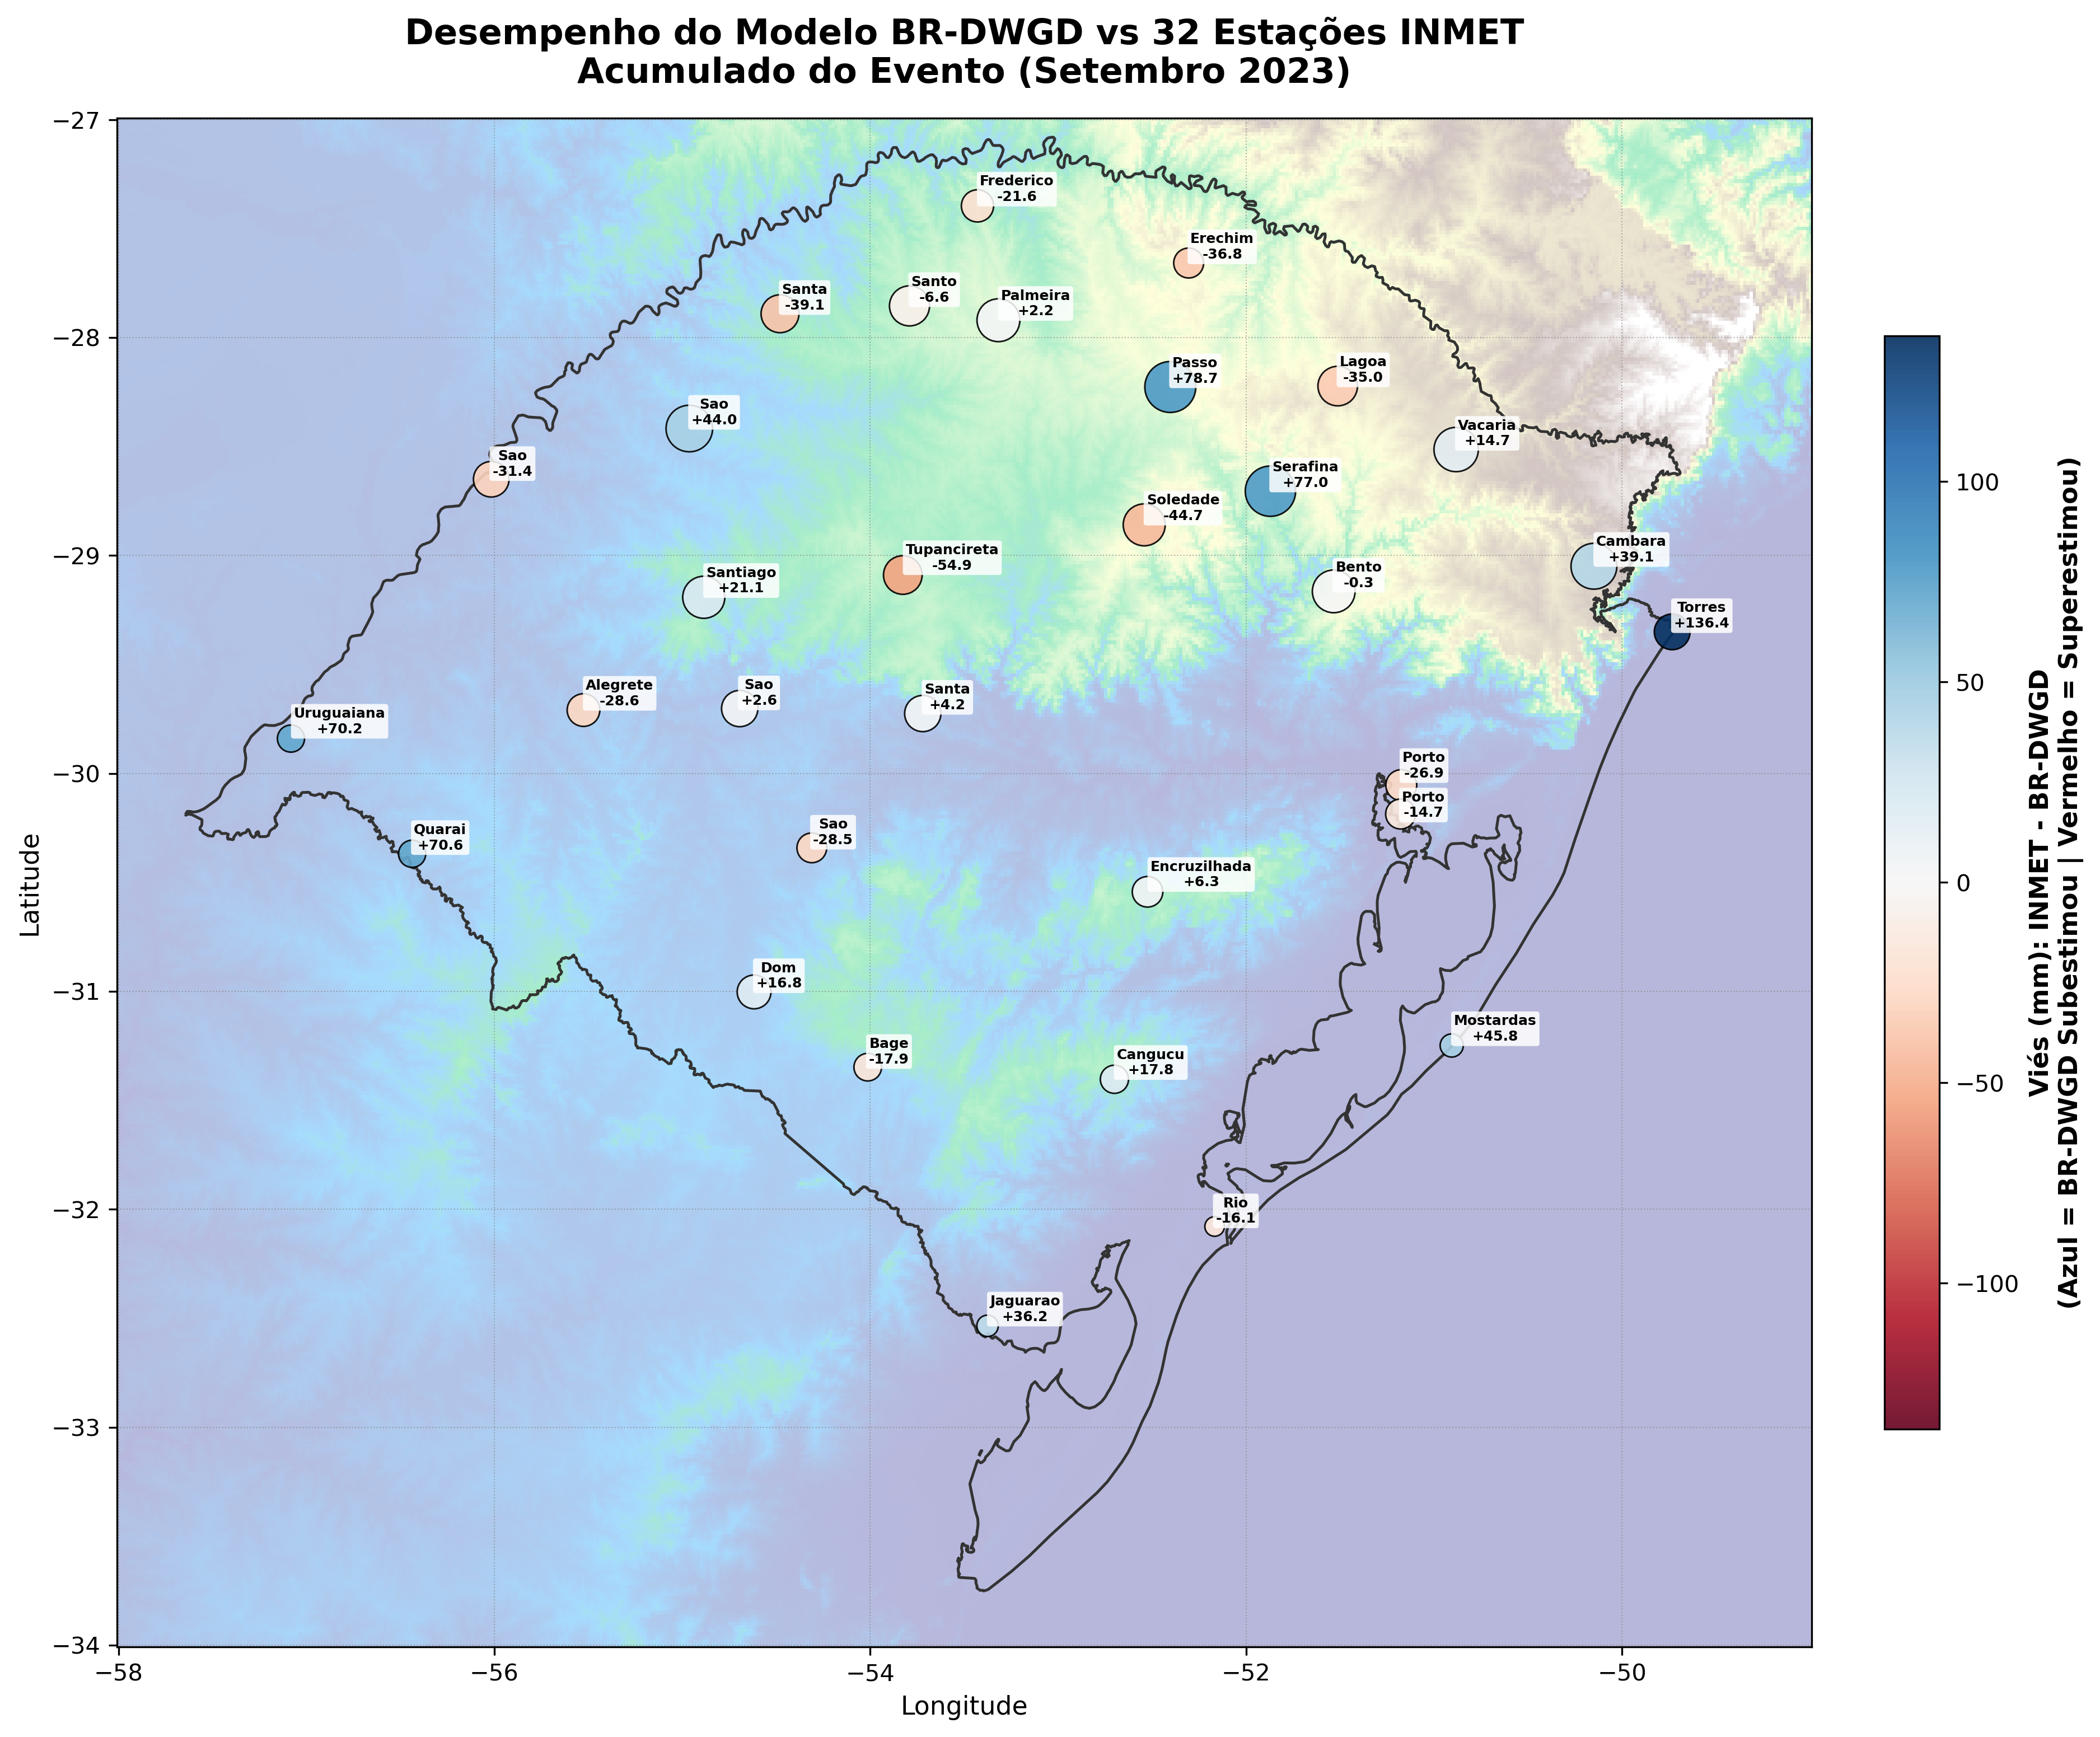

In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import copy
import xarray as xr

# Verifica se o adjustText está disponível
try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
except ImportError:
    HAS_ADJUST_TEXT = False

# 1. CARREGAMENTO DO CONTORNO DO RS
url_br = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brasil = gpd.read_file(url_br)
rs_mapa = brasil[brasil['sigla'] == 'RS']

# 2. CARREGAMENTO DO RELEVO DO RS
caminho_relevo = 'relevo_rs.nc'
TEM_RELEVO = False
relevo_rs = None
try:
    ds_relevo = xr.open_dataset(caminho_relevo)
    var_nomes = [v for v in ds_relevo.data_vars if any(t in v.lower() for t in ['alt', 'elev', 'z', 'topo'])]
    nome_var = var_nomes[0] if var_nomes else list(ds_relevo.data_vars)[0]
    da_relevo = ds_relevo[nome_var].sortby(
        'latitude' if 'latitude' in ds_relevo[nome_var].coords else 'lat'
    ).sortby(
        'longitude' if 'longitude' in ds_relevo[nome_var].coords else 'lon'
    )
    lat_coord = 'latitude' if 'latitude' in da_relevo.coords else 'lat'
    lon_coord = 'longitude' if 'longitude' in da_relevo.coords else 'lon'
    relevo_rs = da_relevo.sel(
        {lat_coord: slice(-34.0, -27.0), lon_coord: slice(-58.0, -49.0)}
    ).clip(min=0)
    TEM_RELEVO = True
except Exception:
    pass

# 3. CONFIGURAÇÃO DA FIGURA (Alta Resolução)
fig, ax = plt.subplots(figsize=(14, 12), dpi=300)

# Fundo do Relevo e Contorno
if TEM_RELEVO and relevo_rs is not None:
    cmap_terrain = copy.copy(plt.get_cmap('terrain'))
    cmap_terrain.set_bad(color='white')
    relevo_rs.plot.imshow(ax=ax, cmap=cmap_terrain, vmin=0, vmax=1400, add_colorbar=False, alpha=0.35, zorder=1)

rs_mapa.boundary.plot(ax=ax, color='#333333', linewidth=1.2, zorder=2)

# 4. PLOTAGEM DAS BOLHAS DE ERRO
# Centraliza a escala de cores no ZERO rigorosamente
limite_erro = max(df_mapa['Diferenca'].abs().max(), 10.0)
norma_cores = colors.TwoSlopeNorm(vcenter=0.0, vmin=-limite_erro, vmax=limite_erro)

sc = ax.scatter(
    df_mapa['Lon'], df_mapa['Lat'],
    s=df_mapa['Chuva_INMET'] * 1.5 + 30, # Tamanho reflete o volume de chuva real
    c=df_mapa['Diferenca'],
    cmap='RdBu', 
    norm=norma_cores,
    edgecolors='black', 
    linewidths=0.7,
    alpha=0.9,
    zorder=3
)

# Barra de Cores
cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Viés (mm): INMET - BR-DWGD\n(Azul = BR-DWGD Subestimou | Vermelho = Superestimou)', fontsize=11, fontweight='bold')

# 5. RÓTULOS (Com sistema anti-colisão)
textos = []
for _, row in df_mapa.iterrows():
    # Limpa o nome para pegar apenas a primeira palavra (ex: "PORTO ALEGRE - JARDIM BOTANICO" vira "Porto")
    nome_curto = str(row['Estacao']).split()[0].split('-')[0].title()
    t = ax.text(
        row['Lon'], row['Lat'], 
        f"{nome_curto}\n{row['Diferenca']:+.1f}",
        fontsize=6, weight='bold', color='#000000', zorder=4,
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.2')
    )
    textos.append(t)
    
if HAS_ADJUST_TEXT:
    adjust_text(textos, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.7), ax=ax)

# 6. ESTÉTICA FINAL
ax.set_title('Desempenho do Modelo BR-DWGD vs 32 Estações INMET\nAcumulado do Evento (Setembro 2023)', 
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.grid(color='grey', linestyle=':', linewidth=0.5, alpha=0.6, zorder=0)

# Salvar e Mostrar
plt.savefig('mapa_erro_brdwgd_inmet_32estacoes.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

mapa de diferença dos métodos apenas com xavier

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import xarray as xr
import warnings
import copy

try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
except ImportError:
    HAS_ADJUST_TEXT = False

warnings.filterwarnings('ignore')

# --- 1. O SEU CÁLCULO ORIGINAL MANTÉM-SE INTACTO ---
lista_comparativo_metodos = []

for index, row in df_aprovadas.iterrows():
    lat, lon = row['Latitude'], row['Longitude']

    # nearest (codigo antigo)
    v_nearest = ds.pr.sel(time=slice(data_inicio, data_fim)).sel(
        latitude=lat, longitude=lon, method='nearest'
    ).sum().values.item()

    # bilinear (codigo atualizado)
    v_bilinear = ds.pr.sel(time=slice(data_inicio, data_fim)).interp(
        latitude=lat, longitude=lon, method='linear'
    ).sum().values.item()

    lista_comparativo_metodos.append({
        'Estacao': row['Nome_Estacao'],
        'Lat': lat,
        'Lon': lon,
        'Nearest': v_nearest,
        'Bilinear': v_bilinear,
        'Dif_Metodos': v_bilinear - v_nearest
    })

df_metodos = pd.DataFrame(lista_comparativo_metodos)

# --- 2. NOVA FORMATAÇÃO VISUAL ---

# Carregamento do contorno do RS
url_br = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brasil = gpd.read_file(url_br)
rs_mapa = brasil[brasil['sigla'] == 'RS']

# Carregamento e corte do Relevo do RS
caminho_relevo = 'relevo_rs.nc'
TEM_RELEVO = False
relevo_rs = None

try:
    ds_relevo = xr.open_dataset(caminho_relevo)
    var_nomes = [v for v in ds_relevo.data_vars if any(t in v.lower() for t in ['alt', 'elev', 'z', 'topo'])]
    nome_var = var_nomes[0] if var_nomes else list(ds_relevo.data_vars)[0]
    
    da_relevo = ds_relevo[nome_var].sortby(
        'latitude' if 'latitude' in ds_relevo[nome_var].coords else 'lat'
    ).sortby(
        'longitude' if 'longitude' in ds_relevo[nome_var].coords else 'lon'
    )
    
    lat_coord = 'latitude' if 'latitude' in da_relevo.coords else 'lat'
    lon_coord = 'longitude' if 'longitude' in da_relevo.coords else 'lon'

    relevo_rs = da_relevo.sel(
        {lat_coord: slice(-34.0, -27.0), lon_coord: slice(-58.0, -49.0)}
    ).clip(min=0)
    TEM_RELEVO = True
except Exception as e:
    print(f'Aviso: Não foi possível processar o relevo ({e}).')

# Configuração da Figura (Alta Resolução)
fig, ax = plt.subplots(figsize=(12, 10), dpi=300)

# Camada 1: Relevo com transparência
if TEM_RELEVO and relevo_rs is not None:
    cmap_terrain = copy.copy(plt.get_cmap('terrain'))
    cmap_terrain.set_bad(color='white')
    relevo_rs.plot.imshow(
        ax=ax, cmap=cmap_terrain, vmin=0, vmax=1400, add_colorbar=False, alpha=0.35, zorder=1
    )

# Camada 2: Contorno do RS
rs_mapa.boundary.plot(ax=ax, color='#333333', linewidth=0.8, zorder=2)

# Camada 3: Bolhas de Diferença (Bilinear - Nearest)
limite_erro = max(df_metodos['Dif_Metodos'].abs().max(), 2.0)
norma_cores = colors.TwoSlopeNorm(vcenter=0.0, vmin=-limite_erro, vmax=limite_erro)

sc = ax.scatter(
    df_metodos['Lon'], df_metodos['Lat'],
    s=df_metodos['Bilinear'] * 2.0 + 20, 
    c=df_metodos['Dif_Metodos'],
    cmap='RdBu', 
    norm=norma_cores,
    edgecolors='white', 
    linewidths=0.6,
    zorder=3
)

cbar_chuva = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
cbar_chuva.set_label('Diferença (mm): Bilinear - Vizinho Próximo', fontsize=11, fontweight='bold')

# Rótulos (Com organização automática para evitar colisões)
textos = []
for _, row in df_metodos.iterrows():
    nome_curto = str(row['Estacao']).split()[0].title()
    t = ax.text(
        row['Lon'], row['Lat'], 
        f"{nome_curto}\n{row['Dif_Metodos']:+.2f} mm",
        fontsize=7, weight='bold', color='#1a1a1a', zorder=4,
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.2')
    )
    textos.append(t)
    
if HAS_ADJUST_TEXT:
    adjust_text(textos, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5), ax=ax)

# Estética Final
ax.set_title('Sensibilidade da Interpolação Espacial: Bilinear vs Vizinho Próximo\n(Setembro 2023)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.grid(color='grey', linestyle=':', linewidth=0.5, alpha=0.5, zorder=0)

plt.savefig('mapa_interpolacao_publicacao.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

NameError: name 'df_aprovadas' is not defined

In [6]:
%pip install rioxarray

Note: you may need to restart the kernel to use updated packages.


In [7]:
print(df_mapa.columns)

Index(['Estacao', 'Lat', 'Lon', 'Chuva_INMET', 'Chuva_Xavier', 'Diferenca'], dtype='object')


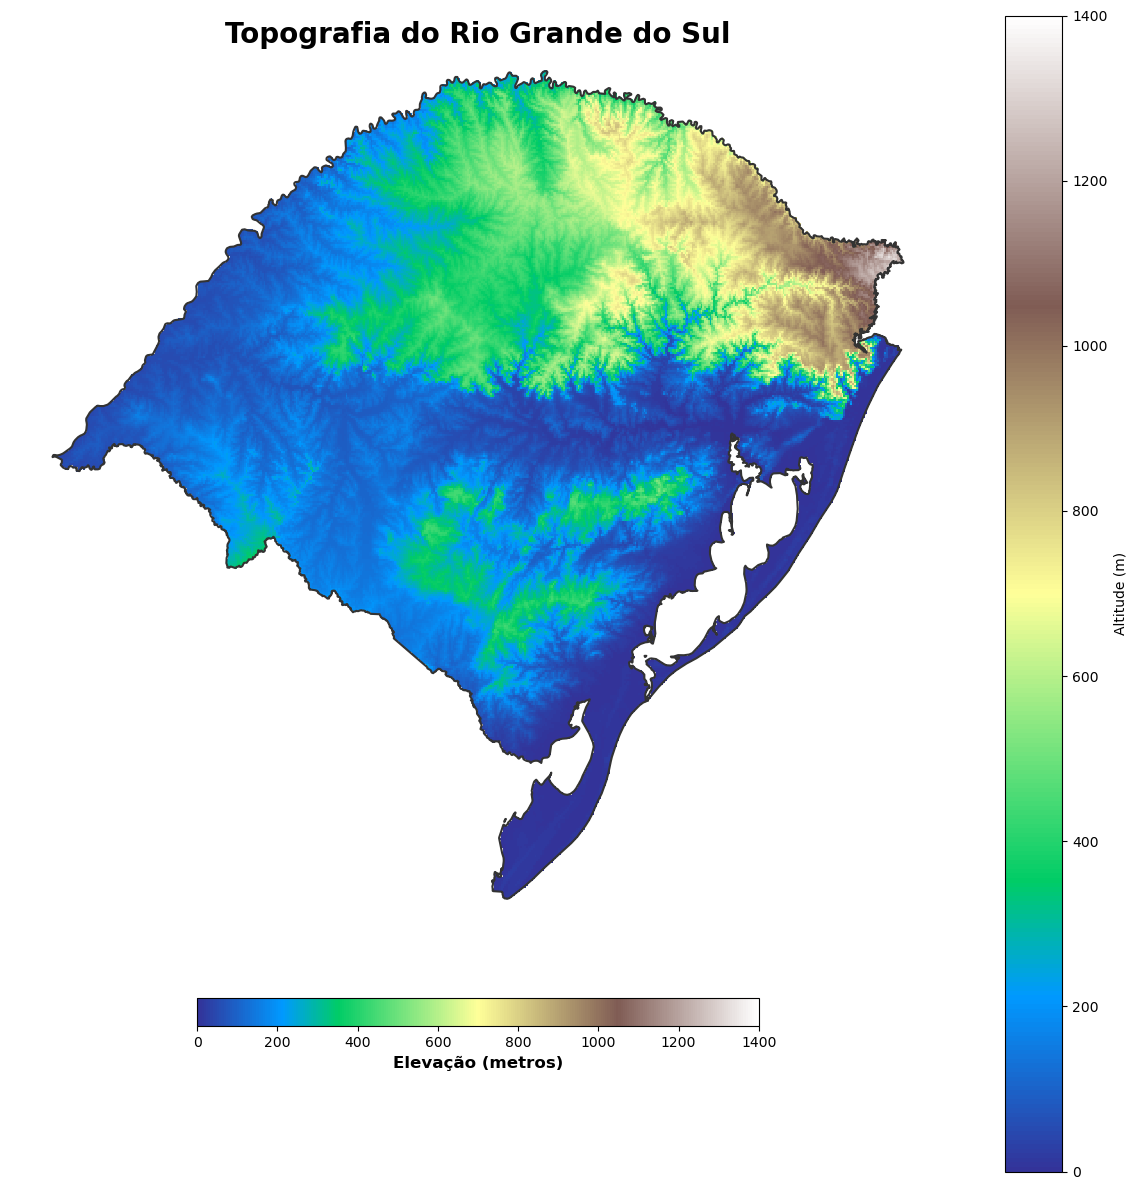

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray
import urllib.request
import copy

# 1. CARREGAMENTO DO CONTORNO DO RS
url_br = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brasil = gpd.read_file(url_br)
rs_mapa = brasil[brasil['sigla'] == 'RS']

# 2. DOWNLOAD E PREPARAÇÃO DO RELEVO
#trecho [(-34.0):1:(-27.0)][(-58.0):1:(-49.0)] é a forma de pedir para o servidor da NOAA recortar os dados antes de você fazer o download. Isso se chama sintaxe OPeNDAP.
#A estrutura é sempre [(Início) : (Salto) : (Fim)]:
#[(-34.0):1:(-27.0)] (Latitude): Pede os dados do paralelo 34°S até o 27°S. Essa é a "altura" exata da caixa que engloba o Rio Grande do Sul.
#[(-58.0):1:(-49.0)] (Longitude): Pede os dados do meridiano 58°W até o 49°W. Essa é a "largura" da caixa.
#O número 1 no meio: É o stride (passo ou salto). Significa "traga 1 a 1", ou seja, faça o download de todos os pixels dessa área. Se você colocasse :2:, o servidor pularia um pixel sim e um não, te entregando um arquivo com metade da resolução (e metade do peso).
#Resumindo: essa linha evita que você baixe o relevo do planeta Terra inteiro (que tem gigabytes de tamanho) e baixa apenas um retângulo contendo o RS.

url_relevo = "https://coastwatch.pfeg.noaa.gov/erddap/griddap/etopo180.nc?altitude[(-34.0):1:(-27.0)][(-58.0):1:(-49.0)]"
nc_file = "relevo_rs.nc"

# Baixa o arquivo NetCDF da NOAA
urllib.request.urlretrieve(url_relevo, nc_file)

# Abre o dado e ajusta as coordenadas para o padrão do rioxarray
ds = xr.open_dataset(nc_file)
ds = ds.rename({'latitude': 'y', 'longitude': 'x'})
ds = ds.rio.write_crs("epsg:4326")

# Recorta o relevo usando o contorno do RS (o que fica de fora vira NaN)
relevo_rs = ds['altitude'].rio.clip(rs_mapa.geometry, rs_mapa.crs, drop=True)

# Limita valores mínimos a 0 (para não pegar profundidade da Lagoa/Oceano)
# O método .clip preserva os NaNs gerados fora das fronteiras
relevo_rs = relevo_rs.clip(min=0)

# 3. CONFIGURAÇÃO E PLOTAGEM
fig, ax = plt.subplots(figsize=(12, 12))

# Cria uma cópia do colormap 'terrain' e define que dados inválidos (NaN) sejam transparentes
cmap_terrain = copy.copy(plt.get_cmap('terrain'))
cmap_terrain.set_bad(color='none')

# Trecho corrigido da plotagem
relevo_plot = relevo_rs.plot.imshow(
    ax=ax, 
    cmap=cmap_terrain, 
    vmin=0, 
    vmax=1400,
    add_colorbar=True,
    cbar_kwargs={'label': 'Altitude (m)'}
)


# Plota o contorno do estado por cima
rs_mapa.plot(ax=ax, facecolor='none', edgecolor='#333333', linewidth=1.5, zorder=2)

# Adiciona a barra de cores do relevo na horizontal
cbar_terrain = plt.colorbar(relevo_plot, ax=ax, shrink=0.6, pad=0.05, orientation='horizontal')
cbar_terrain.set_label('Elevação (metros)', fontsize=12, fontweight='bold')

# Ajustes finais do gráfico
ax.set_title('Topografia do Rio Grande do Sul', fontsize=20, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()

plt.show()


In [12]:
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import copy

# Carregamento do contorno do RS
url_br = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brasil = gpd.read_file(url_br)
rs_mapa = brasil[brasil['sigla'] == 'RS']

# Carregamento do relevo (ajuste o nome do arquivo conforme necessário)
ds_relevo = xr.open_dataset("relevo_rs.nc")
ds_relevo = ds_relevo.rename({'latitude': 'y', 'longitude': 'x'})
ds_relevo = ds_relevo.rio.write_crs("epsg:4326")

# Recorte do relevo para o estado
relevo_rs = ds_relevo['altitude'].rio.clip(rs_mapa.geometry, rs_mapa.crs, drop=True)
relevo_rs = relevo_rs.clip(min=0) # Remove valores abaixo do nível do mar

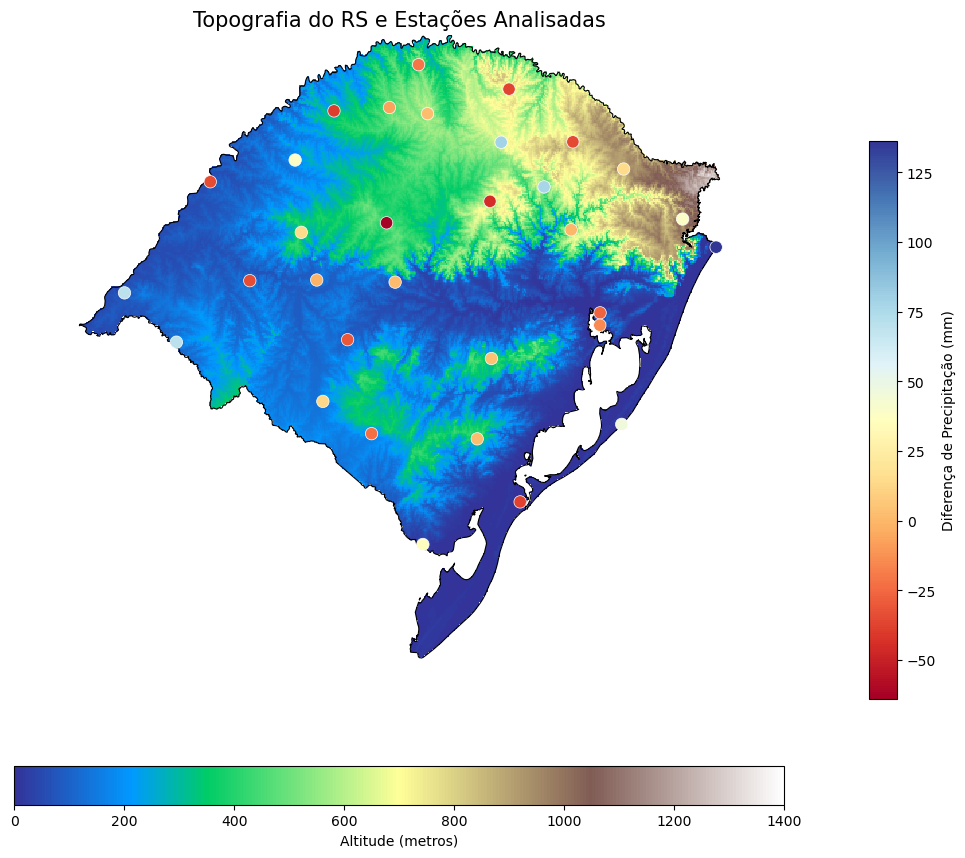

In [ ]:
# 2. CARREGAMENTO E RECORTE DO MAPA
url_br = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brasil = gpd.read_file(url_br)
rs_mapa = brasil[brasil['sigla'] == 'RS']

# Abre o NetCDF e prepara as coordenadas
ds = xr.open_dataset(nc_file)
ds = ds.rename({'latitude': 'y', 'longitude': 'x'})
ds = ds.rio.write_crs("epsg:4326")

# Recorta o relevo exatamente no formato do RS
relevo_rs = ds['altitude'].rio.clip(rs_mapa.geometry, rs_mapa.crs, drop=True)
relevo_rs = relevo_rs.clip(min=0) # Remove o oceano

# 3. PLOTAGEM FINAL (Igual à sua imagem)
fig, ax = plt.subplots(figsize=(12, 10))

# Configura o mapa de cores da topografia
cmap_terrain = copy.copy(plt.get_cmap('terrain'))
cmap_terrain.set_bad(color='none') 

# Camada 1: Topografia (Fundo)
relevo_plot = relevo_rs.plot.imshow(
    ax=ax, 
    cmap=cmap_terrain, 
    vmin=0, 
    vmax=1400,
    add_colorbar=False
)

# Camada 2: Contorno do RS
rs_mapa.boundary.plot(ax=ax, color='black', linewidth=0.8, zorder=2)

# Camada 3: Seus dados (Pontos coloridos)
# Substitua 'df_mapa' pelo nome do seu DataFrame de resultados
if 'df_mapa' in locals():
    sc = ax.scatter(
        df_mapa['Lon'], 
        df_mapa['Lat'], 
        c=df_mapa['Diferenca'], # A cor baseada na diferença
        cmap='RdYlBu',          # Cores para chuva (Azul/Vermelho)
        s=80, 
        edgecolors='white', 
        linewidth=0.5,
        zorder=3
    )
    plt.colorbar(sc, label='Diferença de Precipitação (mm)', fraction=0.03, pad=0.04)

# Adiciona a barra de cores da altitude embaixo
cbar_top = plt.colorbar(relevo_plot, ax=ax, orientation='horizontal', fraction=0.05, pad=0.1)
cbar_top.set_label('Altitude (metros)')

ax.set_title("Topografia do RS e Estações Analisadas", fontsize=15)
ax.set_axis_off()

plt.show()

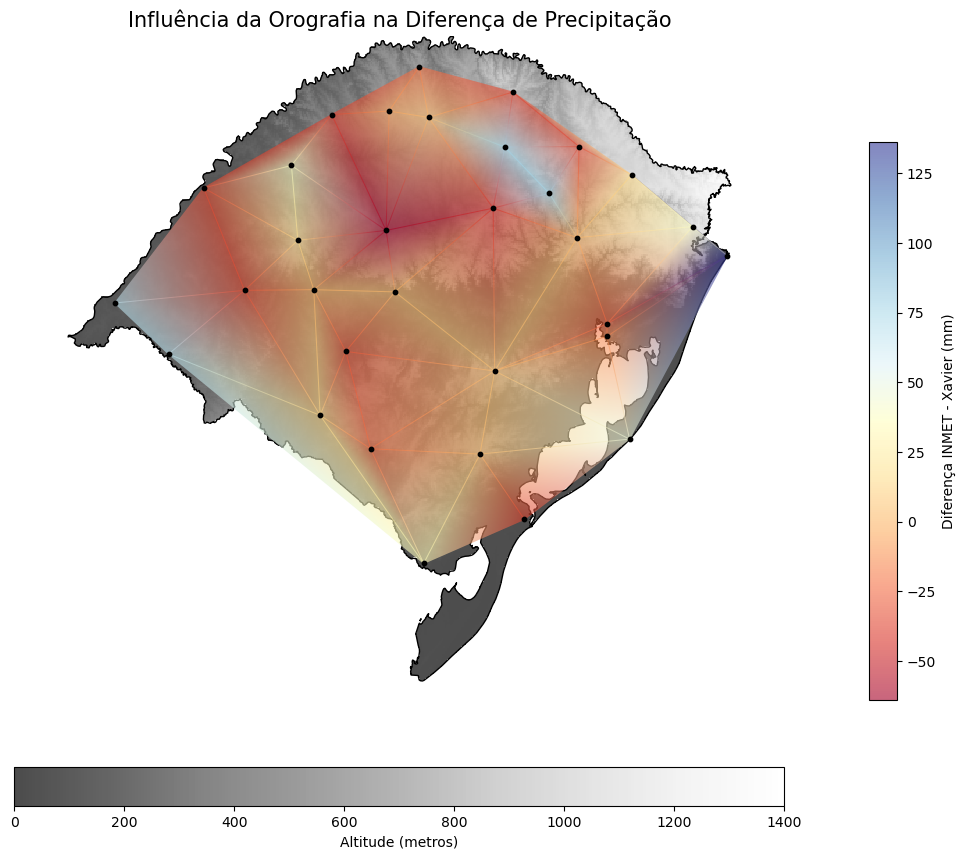

In [18]:
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import urllib.request
import copy
import os

# --- PASSO A: DOWNLOAD DO RELEVO ---
nc_file = "relevo_rs.nc"
if not os.path.exists(nc_file):
    print("Baixando arquivo de relevo... aguarde.")
    url_relevo = "https://pae-paha.pacioos.hawaii.edu/erddap/griddap/etopo1.nc?altitude[(-34.0):1:(-27.0)][(-58.0):1:(-49.0)]"
    urllib.request.urlretrieve(url_relevo, nc_file)
    print("Download concluído!")

# --- PASSO B: CARREGAMENTO E RECORTE ---
url_br = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brasil = gpd.read_file(url_br)
rs_mapa = brasil[brasil['sigla'] == 'RS']

ds = xr.open_dataset(nc_file)
ds = ds.rename({'latitude': 'y', 'longitude': 'x'})
ds = ds.rio.write_crs("epsg:4326")

# Recorta o relevo no formato do RS
relevo_rs = ds['altitude'].rio.clip(rs_mapa.geometry, rs_mapa.crs, drop=True)
relevo_rs = relevo_rs.clip(min=0)

# --- PASSO C: PLOTAGEM ---
fig, ax = plt.subplots(figsize=(12, 10))

# Mapa de cores para o relevo (tons de cinza para destacar a chuva)
cmap_terrain = copy.copy(plt.get_cmap('Greys_r')) 
cmap_terrain.set_bad(color='none') 

# 1. Desenha o Relevo
relevo_plot = relevo_rs.plot.imshow(
    ax=ax, 
    cmap=cmap_terrain, 
    vmin=0, 
    vmax=1400,
    add_colorbar=False,
    alpha=0.7
)

# 2. Desenha o Contorno do Estado
rs_mapa.boundary.plot(ax=ax, color='black', linewidth=1, zorder=2)

# 3. Desenha os seus dados (Diferença de Chuva)
# Usando tripcolor para o efeito de "mancha" (heatmap) da sua imagem
if 'df_mapa' in locals():
    # Cria a superfície colorida
    chuva_plot = ax.tripcolor(
        df_mapa['Lon'], 
        df_mapa['Lat'], 
        df_mapa['Diferenca'],
        cmap='RdYlBu', # Azul para positivo, Vermelho para negativo
        shading='gouraud',
        alpha=0.6,
        zorder=3
    )
    
    # Adiciona os pontos das estações em preto (pequenos)
    ax.scatter(df_mapa['Lon'], df_mapa['Lat'], color='black', s=10, zorder=4)
    
    # Barra de cores da chuva
    plt.colorbar(chuva_plot, label='Diferença INMET - Xavier (mm)', fraction=0.03, pad=0.04)

# Barra de cores da altitude (opcional)
cbar_top = plt.colorbar(relevo_plot, ax=ax, orientation='horizontal', fraction=0.05, pad=0.07)
cbar_top.set_label('Altitude (metros)')

ax.set_title("Influência da Orografia na Diferença de Precipitação", fontsize=15)
ax.set_axis_off()

plt.show()